In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
import time
import numpy as np
from Shapley import ShapNN
from DShap import DShap
import matplotlib.pyplot as plt
import sklearn
from shap_utils import *
%matplotlib inline
MEM_DIR = './'
problem, model = 'classification', 'logistic'
hidden_units = [] # Empty list in the case of logistic regression.
train_size = 2000
d, difficulty = 50, 1
num_classes = 2
tol = 0.03
target_accuracy = 0.7
important_dims = 5
clf = return_model(model, solver='liblinear', hidden_units=tuple(hidden_units))
_param = 1.0
for _ in range(100):
    X_raw = np.random.multivariate_normal(mean=np.zeros(d), cov = np.eye(d), 
                                          size=train_size + 5000)
    _, y_raw, _, _ = label_generator(
        problem, X_raw, param = _param,  difficulty = difficulty, important=important_dims)
    clf.fit(X_raw[:train_size], y_raw[:train_size])
    test_acc = clf.score(X_raw[train_size:], y_raw[train_size:])
    if test_acc > target_accuracy:
        break
    _param *= 1.1
print('Performance using the whole training set = {0:.2f}'.format(test_acc))
X, y = X_raw[:train_size], y_raw[:train_size]
X_test, y_test = X_raw[train_size:], y_raw[train_size:]
model = 'logistic'
problem = 'classification'
num_test = 1000
directory = './temp'
dshap = DShap(X, y, X_test, y_test, num_test, 
              sources=None, 
              sample_weight=None,
              model_family=model, 
              metric='accuracy',
              overwrite=True,
              directory=directory, seed=0)
dshap.run(100, 0.1)

2026-04-10 13:26:35.565946: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-10 13:26:36.118592: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Instructions for updating:
non-resource variables are not supported in the long term
Performance using the whole training set = 0.70
Starting LOO score calculations!
LOO values calculated!
Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


2026-04-10 13:26:48.251030: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-10 13:26:48.251542: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-04-10 13:26:48.432105: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-04-10 13:26:48.444563: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} 

2026-04-10 13:26:51.442221: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-04-10 13:26:51.448542: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an err

2026-04-10 13:26:54.602223: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-04-10 13:26:54.608589: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an err

...

2026-04-10 15:40:25.929217: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-04-10 15:40:25.938557: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an err

90 out of 100 G-Shapley iterations


2026-04-10 15:40:29.068388: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-04-10 15:40:29.077896: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an err

2026-04-10 15:40:42.138164: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-04-10 15:40:42.147153: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an err

100 out of 100 G-Shapley iterations


In [3]:
len(dshap.vals_tmc)

2000

Test set size: 1000
Baseline: 100 training samples → 70.0% accuracy
Adding points: [0, 50, 100, 150, 200, 250, 300]

Verifying baseline performance...
Verified baseline accuracy: 0.6200 (62.00%)

Calculating for method 0...
Sorted 2000 training points by value (lowest first)

  Adding 0 low-value points...
    Training on 100 samples (100 baseline + 0 added)
    Test accuracy: 0.6200 (62.00%)

  Adding 50 low-value points...
    Training on 147 samples (100 baseline + 50 added)
    Test accuracy: 0.4860 (48.60%)

  Adding 100 low-value points...
    Training on 197 samples (100 baseline + 100 added)
    Test accuracy: 0.4230 (42.30%)

  Adding 150 low-value points...
    Training on 245 samples (100 baseline + 150 added)
    Test accuracy: 0.3780 (37.80%)

  Adding 200 low-value points...
    Training on 294 samples (100 baseline + 200 added)
    Test accuracy: 0.3660 (36.60%)

  Adding 250 low-value points...
    Training on 340 samples (100 baseline + 250 added)
    Test accuracy: 0.

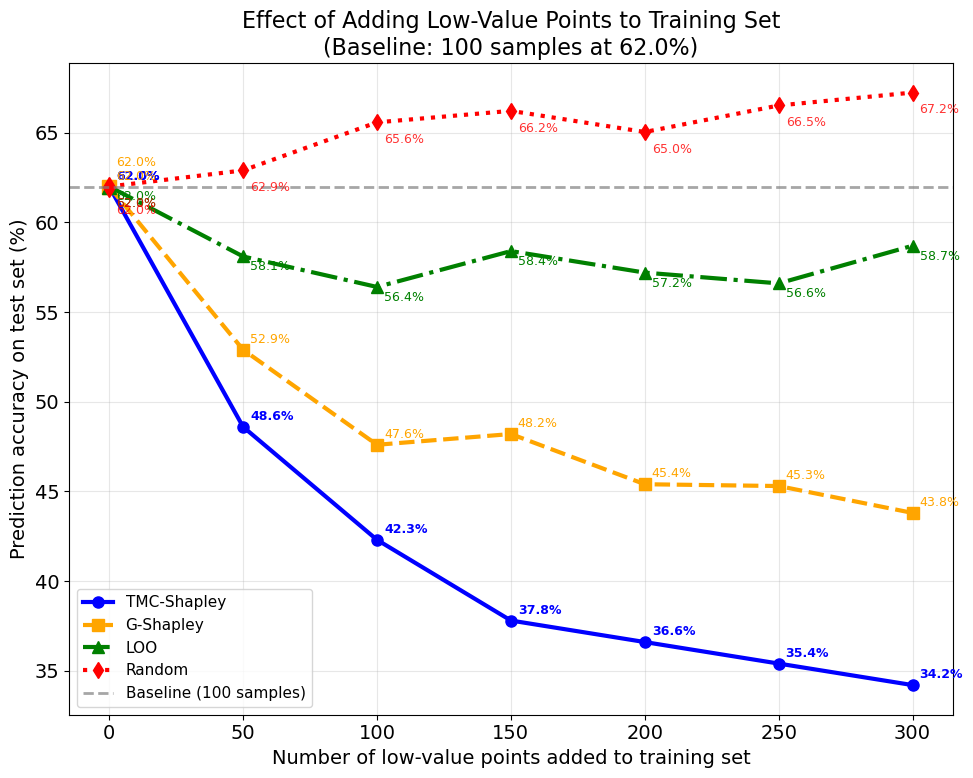


✓ Plot saved to ./temp/plots/addition_analysis_add_low_value.png

COMPLETE!


([0, 0, 50, 100, 150, 200, 250, 300],
 [[0.62, 0.62, 0.486, 0.423, 0.378, 0.366, 0.354, 0.342],
  [0.62, 0.62, 0.529, 0.476, 0.482, 0.454, 0.453, 0.438],
  [0.62, 0.62, 0.581, 0.564, 0.584, 0.572, 0.566, 0.587]],
 array([0.62  , 0.62  , 0.629 , 0.6558, 0.6622, 0.6504, 0.6652, 0.6724]))

<Figure size 1000x800 with 0 Axes>

In [39]:
from DShap import *
%matplotlib inline
dshap.performance_plots_low_rev_add(
    [dshap.vals_tmc, dshap.vals_g, dshap.vals_loo],
    name='addition_analysis',
    num_plot_markers=20,  # Not used in addition mode but kept for compatibility
    sources=dshap.sources,
    add_steps=[0,50,100,150,200,250,300]
)